In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timezone
import os
import numpy as np
import pandas as pd
import xarray as xr
import time

In [2]:
import sys
sys.path.append(os.path.expanduser("../../plot_results"))

from datalakes import download_data_from_datalakes_dataset

### Parameters

In [3]:
lake_name = "geneva"
sta_name = 'geneva_lexplore'

model = 'geneva_artful_01'

In [4]:
var_to_plot = 'THETA'

## Import cropped netcdf MITgcm results

In [5]:
ds_to_plot = xr.open_dataset(r"/storage/alplakes_test/ARTFUL_project/01_2023-09-12/run.nc")

## Import measure

In [6]:
start_date = pd.to_datetime(ds_to_plot['time'].values[0]).to_pydatetime()  #datetime(2024, 1, 1, 0, 0, 0)
end_date = pd.to_datetime(ds_to_plot['time'].values[-1]).to_pydatetime() #datetime(2025, 1, 1, 0, 0, 0)

In [7]:
start_clock = time.time()

xr_measure = download_data_from_datalakes_dataset(667, start_date.replace(tzinfo=timezone.utc), end_date.replace(tzinfo=timezone.utc), "idronaut")

end_clock = time.time()
print(f'Done. Operation took {end_clock - start_clock}s.')

Done. Operation took 32.595672845840454s.


## Plot timeserie

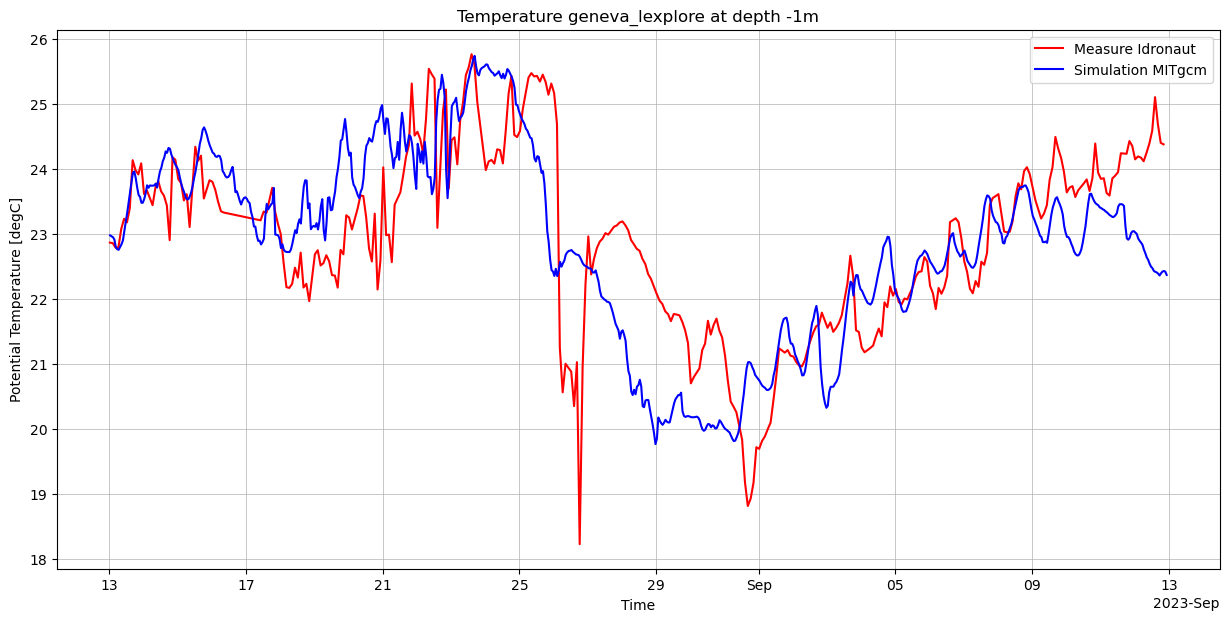

In [14]:
depth_plot=-1 # Value should be negative !!

i_sim_depth_plot = np.argmin(np.abs(ds_to_plot['Z'].values - depth_plot))

fig, ax = plt.subplots(1,1,figsize=(15, 7))

if xr_measure is not None:
    meas_selected = xr_measure['temp'].sel(depth=depth_plot, method='nearest') #.sel(time=slice(start_date,end_date))
    meas_selected.plot(label=f'Measure Idronaut', color='r')

sim_selected=ds_to_plot[var_to_plot].isel(Z=i_sim_depth_plot) #.sel(time=slice(start_date, end_date))
sim_selected.plot(label='Simulation MITgcm', color='b')

plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.legend()
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
plt.title(f"Temperature {sta_name} at depth {depth_plot}m")
plt.show()

#plt.savefig(rf"output_plots\{lake_name}\{model}_{depth_plot}m.png")

# Profile

In [18]:
date_plot_profil = datetime(2023,9,11,12,0,0)
date_plot_profil_str = date_plot_profil.strftime('%Y%m%d%H%M')

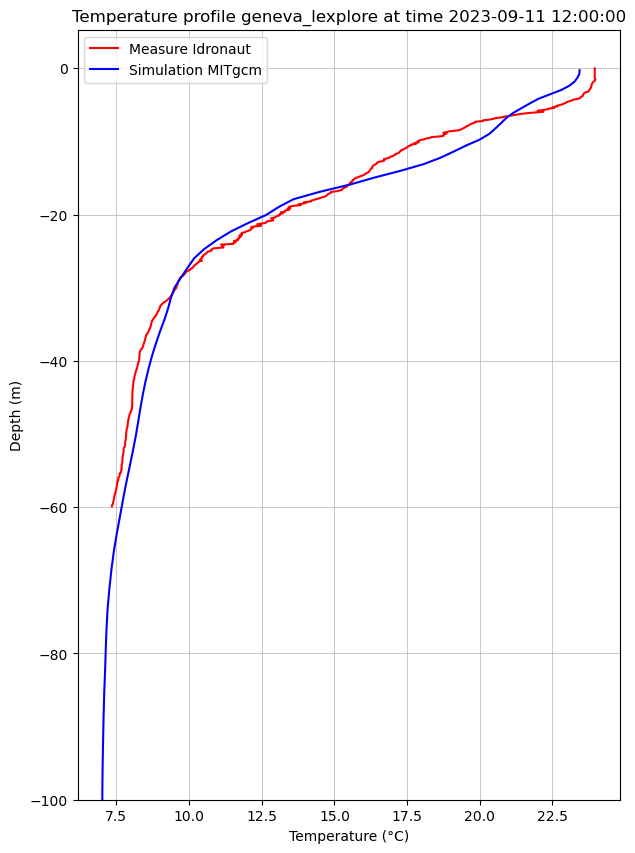

In [19]:
fig = plt.figure(figsize=(7, 10))

meas_profile = xr_measure['temp'].sel(time=date_plot_profil, method='nearest')
plt.plot(meas_profile.values, meas_profile.depth.values, label=f'Measure Idronaut', color='r')

profile_to_plot = ds_to_plot[var_to_plot].sel(time=date_plot_profil, method='nearest')
profile_to_plot.where(profile_to_plot != 0, np.nan).plot(y='Z', label='Simulation MITgcm', color='b')

plt.title(f"Temperature profile {sta_name} at time {date_plot_profil}")
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.ylabel('Depth (m)')
plt.ylim(bottom=-100)
plt.xlabel('Temperature (°C)')
plt.legend()
#plt.savefig(rf"output_plots\{lake_name}\profile_{date_plot_profil.date()}.png")